# KMRF Model - Single Asset Test Notebook


This notebook demonstrates the KMRF (KAMA+MSR+RF) regime prediction pipeline for a single asset:


1. Initialize KMRF model for a specific asset

2. Load pre-computed features and KAMA+MSR labels

3. Adapt 4-regime labels to 3-class KMRF labels

4. Load and combine macroeconomic features

5. Split data into train/validation/test sets

6. (Optional) Feature selection with Boruta

7. Visualize regimes and data


In [1]:
# %pip install -r requirements.txt
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')



import kmrf as kmrf



%matplotlib inline

## 1. Initialize KMRF Model for Specific Asset

In [2]:
# Define asset to analyze
asset_name = 'SPDR S&P 500 ETF'  # SPY
asset_class = 'us_equity'

# asset_name = 'Gold Futures'
# asset_class = 'commodity'



# Initialize KMRF for this specific asset
kmrf_model = kmrf.KMRF(
    asset_name=asset_name,
    asset_class=asset_class,
    end_date='20190101',
    use_ready_data=True,
    validation_start='2019-04-01',
    validation_end='2019-09-30',
    test_start='2020-01-01',
    random_seed=1010
)



print(f"\n{kmrf_model}")

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 to 2019-09-30
  Test start: 2020-01-01
  Random seed: 1010

KMRF('SPDR S&P 500 ETF', us_equity)


## 2. Load Data and Features

In [3]:
# Load data for this asset
data = kmrf_model.load_data()



# Extract pre-computed features
features = kmrf_model.get_features()



print(f"\nData shape: {data.shape}")
print(f"Features shape: {features.shape}")
print(f"Date range: {features.index[0]} to {features.index[-1]}")


Loading data from: data/ready/us_equity.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 9022
  Columns: 112
  Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00

Extracting pre-computed features for SPDR S&P 500 ETF...
  Features shape: (9022, 112)

Data shape: (9022, 112)
Features shape: (9022, 112)
Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00


## 3. Load KAMA+MSR Labels

In [4]:
# Load original 4-regime labels from saved models
original_labels = kmrf_model.load_kama_msr_labels()


LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Model directory: saved_models/KAMA_MSR/us_equity/20190101
Loading from: SPDR S&P 500 ETF_KAMA-MSR_4-regimes.pkl
✓ Loaded labels for: SPDR S&P 500 ETF
  Label date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Total periods: 6041

  Original 4-regime distribution:
    0 -   LV Bullish:  4560 ( 75.7%)
    1 -   LV Bearish:  1138 ( 18.9%)
    2 -   HV Bullish:    26 (  0.4%)
    3 -   HV Bearish:   299 (  5.0%)


## 4. Adapt Labels (4-regime → 3-class)

In [5]:
# Adapt to 3-class KMRF labels
adapted_labels = kmrf_model.adapt_regime_labels()


ADAPTING REGIME LABELS FOR SPDR S&P 500 ETF

  Adapted 3-class distribution:
     Bullish ( 1):  4908 ( 81.2%)
       Other ( 0):   312 (  5.2%)
     Bearish (-1):   821 ( 13.6%)


## 5. Visualize Adapted Labels on Price Chart

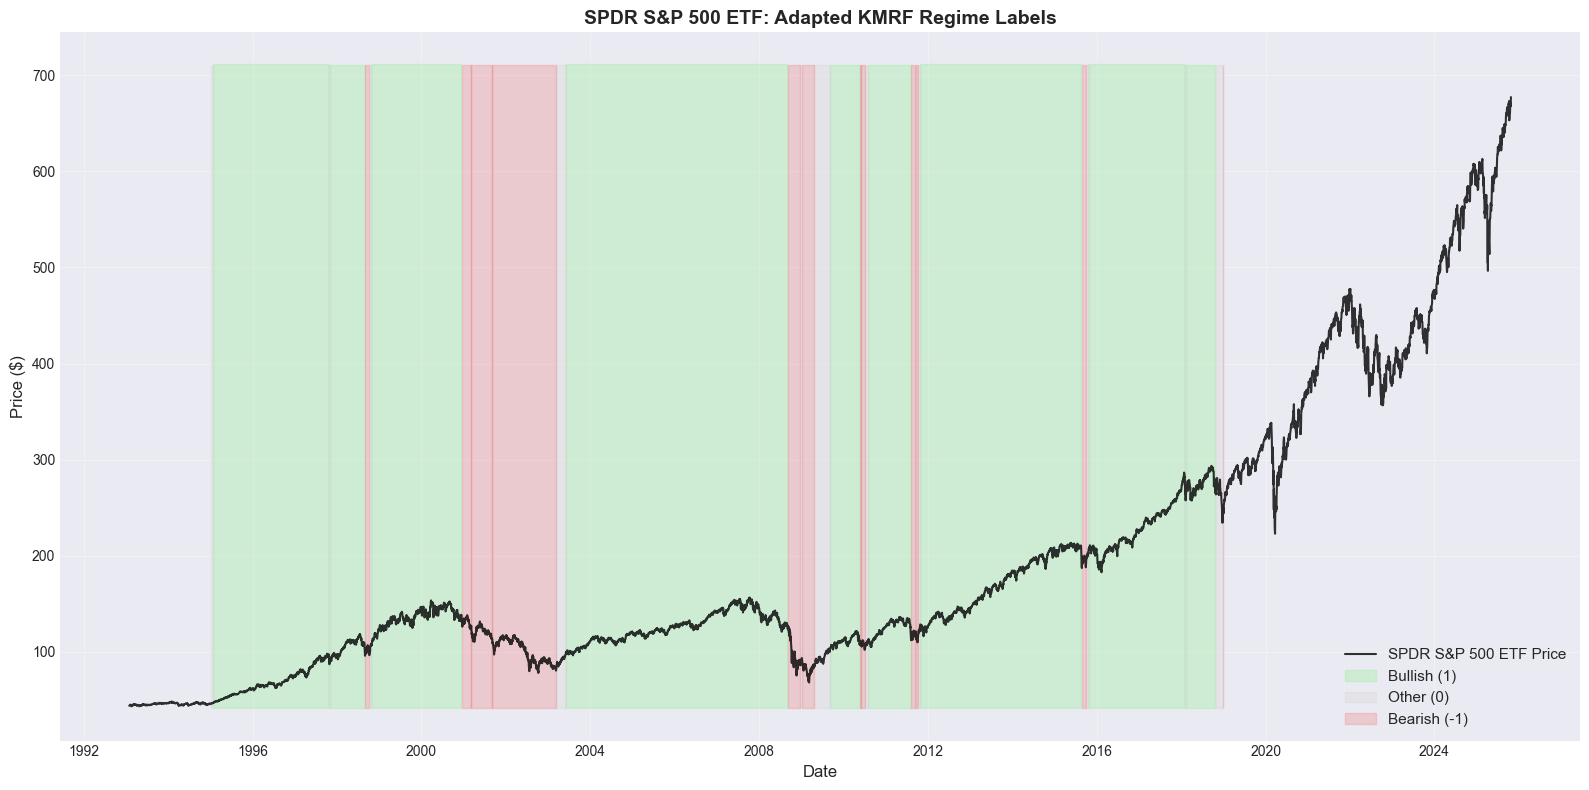

✓ Visualization complete!


In [6]:
# Get close price
close_cols = [col for col in features.columns if 'close' in col.lower() and 'sma' not in col.lower()]
close_price = features[close_cols[0]] if close_cols else None



if close_price is not None:
    fig, ax = plt.subplots(figsize=(16, 8))
    

    # Plot price
    ax.plot(close_price.index, close_price, color='black', linewidth=1.5, 
            alpha=0.8, label=f'{asset_name} Price', zorder=3)
    

    # Define colors
    colors = {1: 'lightgreen', 0: 'lightgray', -1: 'lightcoral'}
    labels_dict = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
    

    # Shade regions
    for regime in [1, 0, -1]:
        mask = adapted_labels == regime
        if mask.any():
            ax.fill_between(
                close_price.index,
                close_price.min() * 0.95,
                close_price.max() * 1.05,
                where=mask.reindex(close_price.index, fill_value=False),
                alpha=0.3,
                color=colors[regime],
                label=f'{labels_dict[regime]} ({regime})',
                zorder=1
            )
    

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.set_title(f'{asset_name}: Adapted KMRF Regime Labels', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3, zorder=2)
    

    plt.tight_layout()
    plt.show()
    

    print("✓ Visualization complete!")

else:
    print("Price data not available")

## 6. Prepare Training Data with Train/Val/Test Split



**New Feature:** Data is automatically split into:

- **Training**: All data before 2019-04-01

- **Validation**: 2019-04-01 to 2019-09-30

- **Test**: 2020-01-01 onwards



Set `select_features=True` to use Boruta feature selection (applied only on training data)

In [7]:
# Prepare training data with automatic splitting
# Set select_features=True to use Boruta (may take time)
X_train, y_train = kmrf_model.prepare_training_data(
    transform_labels=True,
    include_macro=True,
    select_features=False,  # Set to True to use Boruta
    split_data=True  # Automatically creates train/val/test splits
)
X_train


PREPARING TRAINING DATA FOR SPDR S&P 500 ETF

Step 1: Technical Features
  Features Shape: (9022, 112)

Step 2: Loading Macroeconomic Data

Loading macroeconomic data from: data/ready/macro_data_all.csv
Aligned macro data to features index
Macro data shape: (9022, 52)
Macro indicators: 52
  Combined shape: (9022, 164)

Step 3: Using Pre-Adapted Labels
  (3-class labels from previous adapt_regime_labels() call)
  Labels Shape: (6041,)

Step 4: Cleaning Features - start when labels exist
  Features date range: 1995-01-04 00:00:00 to 2025-10-24 00:00:00
  Labels date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Dropping 3 features with >50% NaN values
  Features ready across full date range

Step 5: Splitting Data
  Train/Validation/Test Split:
    Training   : Before 2019-04-01
    Validation : 2019-04-01 to 2019-09-30
    Test       : 2020-01-01 to End

  Split sizes:
    Training   : 6041 samples with labels (1995-01-04 to 2018-12-31)
    Validation : 127 samples (features only

,open,high,low,close,volume,vwap,log_ret,log_ret_5d,log_ret_10d,log_ret_20d,...,"(Real Gross Domestic Product (GDPC1), Billions of Chained 2017 Dollars, quarterly)","(Real GDP Per Capita (A939RX0Q048SBEA), Chained 2017 Dollars, quarterly)","(Federal Government Debt to GDP Ratio (GFDEGDQ188S), Percent of GDP, quarterly)","(Gross Private Domestic Investment (GPDI), Billions of Dollars, quarterly)","(Real Gross Private Domestic Investment (GPDIC1), Billions of Chained 2017 Dollars, quarterly)","(Foreign Direct Investment in the United States (BOGZ1FU263092001Q), Millions of Dollars, quarterly)","(Balance Sheet - Total Assets (QBPBSTAS), Millions of Dollars, quarterly)","(Federal Debt Held by Federal Reserve Banks (FDHBFRBN), Billions of Dollars, quarterly)","(Federal Debt Held by the Public (FYGFDPUN), Millions of Dollars, quarterly)","(Federal Debt Held by Foreign Investors (FDHBFIN), Billions of Dollars, quarterly)"
date,,,,,,,,,,,,,,,,,,,,,
1995-01-04,45.98,46.00,45.75,46.00,351800.0,45.875,0.004794,-0.006717,0.004139,0.008514,...,11152.176,42264.0,64.01176,1251.749,1531.670,14623.0,4.932364e+06,353.000,3479652.0,682.0
1995-01-05,46.03,46.11,45.95,46.00,89800.0,46.030,0.000000,-0.001738,0.007200,0.007857,...,11152.176,42264.0,64.01176,1251.749,1531.670,14623.0,4.932364e+06,353.000,3479652.0,682.0
1995-01-06,46.09,46.25,45.91,46.05,448400.0,46.080,0.001086,-0.001302,-0.002386,0.016200,...,11152.176,42264.0,64.01176,1251.749,1531.670,14623.0,4.932364e+06,353.000,3479652.0,682.0
1995-01-09,46.03,46.09,46.00,46.09,36800.0,46.045,0.000868,0.011566,0.001520,0.026604,...,11152.176,42264.0,64.01176,1251.749,1531.670,14623.0,4.932364e+06,353.000,3479652.0,682.0
1995-01-10,46.20,46.39,46.14,46.14,229800.0,46.265,0.001084,0.007833,0.001735,0.023907,...,11152.176,42264.0,64.01176,1251.749,1531.670,14623.0,4.932364e+06,353.000,3479652.0,682.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,239.04,240.84,234.27,234.34,147311600.0,237.555,-0.026778,-0.085901,-0.119441,-0.116331,...,20304.874,61619.0,105.04941,3802.028,3724.752,80658.0,1.794299e+07,2594.652,16120742.0,6270.1
2018-12-26,235.97,246.18,233.76,246.18,218485400.0,239.970,0.049290,-0.035514,-0.070378,-0.083057,...,20304.874,61619.0,105.04941,3802.028,3724.752,80658.0,1.794299e+07,2594.652,16120742.0,6270.1
2018-12-27,242.57,248.29,238.96,248.07,186267300.0,243.625,0.007648,-0.012777,-0.067753,-0.078767,...,20304.874,61619.0,105.04941,3802.028,3724.752,80658.0,1.794299e+07,2594.652,16120742.0,6270.1


## 7. Examine Data Splits

In [8]:
print(f"\n{'='*80}")

print(f"DATA SPLITS FOR {asset_name}")

print(f"{'='*80}")



print(f"\nTraining Set:")

print(f"  Shape: {kmrf_model.X_train.shape}")

print(f"  Date range: {kmrf_model.X_train.index[0].date()} to {kmrf_model.X_train.index[-1].date()}")

print(f"  Features used: {kmrf_model.X_train.shape[1]}")

print(f"  Label distribution:")

for label, name in [(1, 'Bullish'), (0, 'Other'), (-1, 'Bearish')]:

    count = (kmrf_model.y_train == label).sum()

    pct = (count / len(kmrf_model.y_train)) * 100

    print(f"    {name:>8}: {count:>5} ({pct:>5.1f}%)")



print(f"\nValidation Set:")

print(f"  Shape: {kmrf_model.X_val.shape}")

print(f"  Date range: {kmrf_model.X_val.index[0].date()} to {kmrf_model.X_val.index[-1].date()}")

print(f"  Features used: {kmrf_model.X_val.shape[1]}")

# print(f"  Label distribution:")

# for label, name in [(1, 'Bullish'), (0, 'Other'), (-1, 'Bearish')]:

#     count = (kmrf_model.y_val == label).sum()

#     pct = (count / len(kmrf_model.y_val)) * 100

#     print(f"    {name:>8}: {count:>5} ({pct:>5.1f}%)")



print(f"\nTest Set:")

print(f"  Shape: {kmrf_model.X_test.shape}")

print(f"  Date range: {kmrf_model.X_test.index[0].date()} to {kmrf_model.X_test.index[-1].date()}")

print(f"  Features used: {kmrf_model.X_test.shape[1]}")

# print(f"  Label distribution:")

# for label, name in [(1, 'Bullish'), (0, 'Other'), (-1, 'Bearish')]:

#     count = (kmrf_model.y_test == label).sum()

#     pct = (count / len(kmrf_model.y_test)) * 100

#     print(f"    {name:>8}: {count:>5} ({pct:>5.1f}%)")



print(f"\n{'='*80}")


DATA SPLITS FOR SPDR S&P 500 ETF

Training Set:
  Shape: (6041, 161)
  Date range: 1995-01-04 to 2018-12-31
  Features used: 161
  Label distribution:
     Bullish:  4908 ( 81.2%)
       Other:   312 (  5.2%)
     Bearish:   821 ( 13.6%)

Validation Set:
  Shape: (127, 161)
  Date range: 2019-04-01 to 2019-09-30
  Features used: 161

Test Set:
  Shape: (1463, 161)
  Date range: 2020-01-02 to 2025-10-24
  Features used: 161



## 8. Feature Analysis

In [9]:
# Analyze feature types
feature_names = kmrf_model.X_train.columns.tolist()


print(f"\nFeature Analysis for {asset_name}:")
print(f"{'='*60}")
print(f"Total features: {len(feature_names)}")
print(f"\nFeature Types:")
print(f"  Returns: {len([f for f in feature_names if 'ret' in str(f).lower()])}")
print(f"  Volatility: {len([f for f in feature_names if 'vol' in str(f).lower()])}")
print(f"  Momentum: {len([f for f in feature_names if 'momentum' in str(f).lower() or 'rsi' in str(f).lower()])}")
print(f"  Technical: {len([f for f in feature_names if any(x in str(f).lower() for x in ['sma', 'ema', 'bb_', 'macd'])])}")
print(f"  Tsfresh: {len([f for f in feature_names if 'tsfresh' in str(f).lower()])}")


print(f"\n{'='*60}")


Feature Analysis for SPDR S&P 500 ETF:
Total features: 161

Feature Types:
  Returns: 7
  Volatility: 37
  Momentum: 8
  Technical: 18
  Tsfresh: 40



## 9. Train Random Forest Model

In [10]:
print("\n" + "="*80)
print("TRAINING RANDOM FOREST MODEL")
print("="*80)

# Train the Random Forest classifier
kmrf_model.fit(kmrf_model.X_train, kmrf_model.y_train)

print("\n✓ Model training complete!")


TRAINING RANDOM FOREST MODEL

TRAINING RANDOM FOREST CLASSIFIER
RF Parameters:
  n_estimators: 220
  max_depth: 13
  min_samples_split: 76
  min_samples_leaf: 95
  max_samples: 0.36
  max_features: 0.25
  min_weight_fraction_leaf: 0.045
  random_state: 1010
  n_jobs: -1

Training samples: 6040
Features: 161
Date range: 1995-01-04 00:00:00 to 2018-12-28 00:00:00

Fitting Random Forest...

TRAINING COMPLETE
Model ready for prediction

✓ Model training complete!


## 10. Generate Predictions on Test Set

In [11]:
print("\n" + "="*80)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*80)

# Generate predictions for the test set
test_predictions = kmrf_model.predict(kmrf_model.X_test, return_proba=True)

print(f"\nTest predictions generated:")
print(f"  Shape: {test_predictions.shape}")
print(f"  Date range: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")

# Show sample predictions
print(f"\nSample predictions (first 10 rows):")
print(test_predictions.head(10).round(4))

# Get predicted regimes (highest probability class)
predicted_regimes = kmrf_model.predict(kmrf_model.X_test, return_proba=False)
predicted_regimes_series = pd.Series(predicted_regimes, index=test_predictions.index)

print(f"\nPredicted regime distribution:")
for regime, name in [(-1, 'Bearish'), (0, 'Other'), (1, 'Bullish')]:
    count = (predicted_regimes_series == regime).sum()
    pct = (count / len(predicted_regimes_series)) * 100
    print(f"  {name:>8} ({regime:>2}): {count:>5} ({pct:>5.1f}%)")


GENERATING PREDICTIONS ON TEST SET

Generating predictions...
Generated probability predictions: (1463, 3)

Test predictions generated:
  Shape: (1463, 3)
  Date range: 2020-01-02 to 2025-10-24

Sample predictions (first 10 rows):
            P(Bearish)  P(Other)  P(Bullish)
date                                        
2020-01-02      0.0060    0.0794      0.9146
2020-01-03      0.0061    0.0782      0.9157
2020-01-06      0.0060    0.0788      0.9152
2020-01-07      0.0060    0.0797      0.9143
2020-01-08      0.0060    0.0788      0.9152
2020-01-09      0.0060    0.0794      0.9146
2020-01-10      0.0058    0.0754      0.9188
2020-01-13      0.0052    0.0714      0.9234
2020-01-14      0.0050    0.0692      0.9258
2020-01-15      0.0051    0.0693      0.9256

Generating predictions...
Generated class predictions: 1463

Predicted regime distribution:
   Bearish (-1):     0 (  0.0%)
     Other ( 0):   467 ( 31.9%)
   Bullish ( 1):   996 ( 68.1%)


## 11. Visualize Predicted Regimes on SPY Price

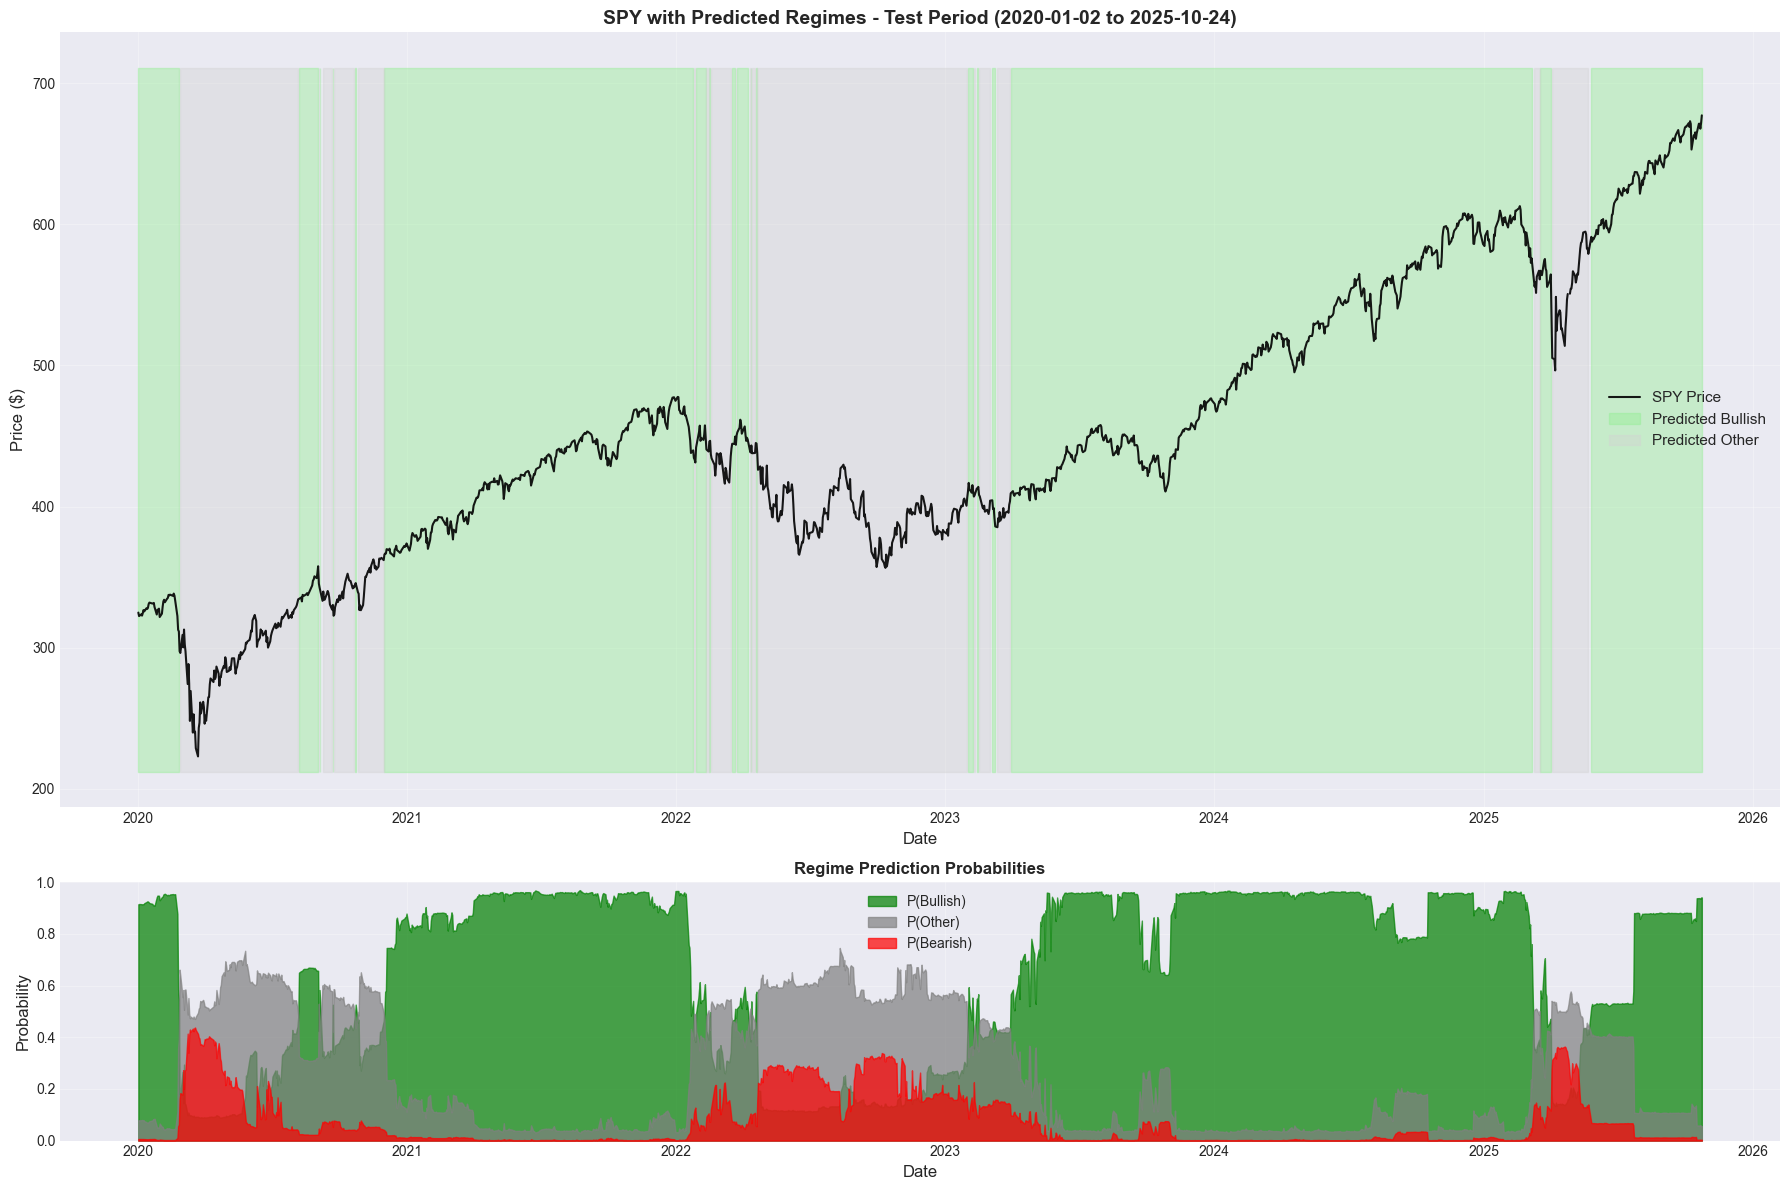


✓ Regime visualization complete!

PREDICTION SUMMARY FOR SPY
Test Period: 2020-01-02 to 2025-10-24
Total Trading Days: 1463

Price Performance:
  Start Price: $324.87
  End Price: $677.25
  Total Return: 108.47%

Regime Prediction Statistics:
   Bearish:   0 days (  0.0%) | Avg Prob: 0.075
     Other: 467 days ( 31.9%) | Avg Prob: 0.265
   Bullish: 996 days ( 68.1%) | Avg Prob: 0.660

High Confidence Predictions (>70%): 835 days (57.1%)

Note: According to the contrarian strategy:
  - High P(Bullish) → SHORT signal (overbought)
  - High P(Bearish) → LONG signal (oversold)
  - High P(Other) → CLOSE position

KMRF MODEL TRAINING AND PREDICTION COMPLETE


In [12]:
# Get full price data and filter for test period
spy_price_full = kmrf_model.features['close']
spy_price_test = spy_price_full.loc[test_predictions.index]

if spy_price_test is not None:
    # Create comprehensive visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), height_ratios=[3, 1])
    
    # === Price Plot with Regime Overlays ===
    # Plot SPY price
    ax1.plot(spy_price_test.index, spy_price_test, color='black', linewidth=1.5, 
             alpha=0.9, label='SPY Price', zorder=3)
    
    # Define colors for regimes
    colors = {1: 'lightgreen', 0: 'lightgray', -1: 'lightcoral'}
    labels_dict = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
    
    # Shade regime periods
    for regime in [1, 0, -1]:
        mask = predicted_regimes_series == regime
        if mask.any():
            ax1.fill_between(
                spy_price_test.index,
                spy_price_test.min() * 0.95,
                spy_price_test.max() * 1.05,
                where=mask,
                alpha=0.4,
                color=colors[regime],
                label=f'Predicted {labels_dict[regime]}',
                zorder=1
            )
    
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title(f'SPY with Predicted Regimes - Test Period ({test_predictions.index[0].date()} to {test_predictions.index[-1].date()})', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, zorder=2)
    
    # === Regime Probabilities ===
    # Plot regime probabilities
    ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bullish)'], 
                     alpha=0.7, color='green', label='P(Bullish)')
    ax2.fill_between(test_predictions.index, 0, test_predictions['P(Other)'], 
                     alpha=0.7, color='gray', label='P(Other)')
    ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bearish)'], 
                     alpha=0.7, color='red', label='P(Bearish)')
    
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Regime Prediction Probabilities', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Regime visualization complete!")
    
    # === Summary Statistics ===
    print(f"\n" + "="*60)
    print(f"PREDICTION SUMMARY FOR SPY")
    print(f"="*60)
    print(f"Test Period: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")
    print(f"Total Trading Days: {len(test_predictions)}")
    
    # Price performance during test period
    price_start = spy_price_test.iloc[0]
    price_end = spy_price_test.iloc[-1]
    total_return = (price_end - price_start) / price_start * 100
    
    print(f"\nPrice Performance:")
    print(f"  Start Price: ${price_start:.2f}")
    print(f"  End Price: ${price_end:.2f}")
    print(f"  Total Return: {total_return:.2f}%")
    
    # Regime statistics
    print(f"\nRegime Prediction Statistics:")
    for regime, name in [(-1, 'Bearish'), (0, 'Other'), (1, 'Bullish')]:
        count = (predicted_regimes_series == regime).sum()
        pct = (count / len(predicted_regimes_series)) * 100
        avg_prob = test_predictions['P(' + labels_dict[regime] + ')'].mean()
        print(f"  {name:>8}: {count:>3} days ({pct:>5.1f}%) | Avg Prob: {avg_prob:.3f}")
    
    # High confidence predictions
    high_confidence = test_predictions.max(axis=1) > 0.7
    print(f"\nHigh Confidence Predictions (>70%): {high_confidence.sum()} days ({high_confidence.mean()*100:.1f}%)")
    
    print(f"\nNote: According to the contrarian strategy:")
    print(f"  - High P(Bullish) → SHORT signal (overbought)")
    print(f"  - High P(Bearish) → LONG signal (oversold)")
    print(f"  - High P(Other) → CLOSE position")

else:
    print("Error: Could not find SPY price data for visualization")

print("\n" + "="*80)
print("KMRF MODEL TRAINING AND PREDICTION COMPLETE")
print("="*80)

## Summary



This notebook demonstrated the complete KMRF data preparation pipeline for a single asset:


### Completed Steps:

1. ✓ Initialized KMRF model for specific asset (SPY)

2. ✓ Loaded asset data and pre-computed features

3. ✓ Loaded KAMA+MSR 4-regime labels from saved models

4. ✓ Adapted labels to 3-class KMRF format (Bullish/Bearish/Other)

5. ✓ Visualized adapted labels on price chart

6. ✓ Prepared data with macroeconomic features

7. ✓ Split data into train/validation/test sets

8. ✓ Trained Random Forest classifier

9. ✓ Generated predictions on test set

10. ✓ Visualized predicted regimes on SPY price plot


### Key Changes from Previous Version:

- **Single Asset Focus**: Each KMRF instance now handles one asset

- **Automatic Data Splitting**: Train/Validation/Test splits with predefined dates

- **Updated Boruta**: Uses standard `boruta` package instead of `BorutaShap`

- **No SciPy Issues**: Compatible with modern SciPy versions

- **Model Training**: Complete Random Forest training pipeline

- **Regime Prediction**: Ex-ante regime predictions with probability output

- **Visualization**: Comprehensive regime overlay on price charts


### Data Splits:

- **Training**: Pre-2019-04-01 (model training)

- **Validation**: 2019-04-01 to 2019-09-30 (hyperparameter tuning)

- **Test**: 2020-01-01 onwards (final evaluation)


### Next Steps:

1. Hyperparameter optimization using validation set

2. Model evaluation on test set

3. Apply contrarian trading strategy:

   - High P(Bullish) → Short (overbought)

   - High P(Bearish) → Long (oversold)

   - High P(Other) → Close position

4. Calculate performance metrics (MCC, Sortino Ratio, Information Ratio)

5. Backtest trading strategy


### Paper References:

- Pomorski & Gorse (2023): "Improving Portfolio Performance Using a Novel Method for Predicting Financial Regimes"

- Feature selection reduces features significantly while maintaining predictive power

- Contrarian interpretation crucial for profitability